# Day 4-3: Class Imbalance 처리

**강의 시간**: 2시간  
**학습 목표**:
- Class Weights 적용
- Focal Loss 구현
- 균형 잡힌 성능 달성
- COVID Recall 95%+ 복원

**사전 요구사항**: Day 4-2 완료  
**Day 4-2 성능**: Accuracy 90.67%, COVID Recall 88.93%

## 🔧 0. 환경 설정 (Day 4-2 계속)

In [1]:
# 라이브러리 설치
%pip install -q 'mlflow>=2,<3' dagshub tensorflow opencv-python scikit-learn

print("✅ 라이브러리 설치 완료!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.4/263.4 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 808.4/808.4 kB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.

In [2]:
# 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    classification_report, confusion_matrix,
    balanced_accuracy_score, recall_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import mlflow
import dagshub

np.random.seed(42)
tf.random.set_seed(42)

print(f"✅ TensorFlow {tf.__version__}")

✅ TensorFlow 2.19.0


In [3]:
# 시각화 설정
sns.set_style('whitegrid')

# 1) 폰트 파일 직접 다운로드 (런타임 재시작 불필요)
!wget -q -O NanumGothic.ttf -L "https://fonts.gstatic.com/ea/nanumgothic/v5/NanumGothic-Regular.ttf"

import matplotlib.font_manager as fm

# 폰트 파일 경로
font_path = "NanumGothic.ttf"

# 폰트 매니저에 폰트 추가
fm.fontManager.addfont(font_path)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

# 폰트 속성 설정
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["axes.unicode_minus"] = False

In [4]:
# MLflow 설정
import mlflow
import dagshub

# 🔥 본인의 정보로 수정!
repo_owner = 'dev.codecompose'  # 본인의 Dagshub username
repo_name = 'deeplearning-bootcamp'  # 생성한 repository 이름 (예: deeplearning-bootcamp)

dagshub.init(repo_owner=repo_owner, repo_name=repo_name, mlflow=True)
mlflow.set_experiment('day4-covid-xray-classification')

print("✅ MLflow 설정 완료!")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=d9437c2e-6872-4067-a66c-77765e8416ed&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=bd42ecf9c8ed7f60b9b47cd47625eb338038d8a595b505581f7ea3c43876205a




Accessing as dev.codecompose

Initialized MLflow to track repo "dev.codecompose/deeplearning-bootcamp"

Repository dev.codecompose/deeplearning-bootcamp initialized!

✅ MLflow 설정 완료!


## 📂 1. 데이터 로드 (Day 4-2 계속)

## 📦 1. 데이터 다운로드

### Kaggle API 설정

**사전 준비**:
1. Kaggle 계정 생성 (https://www.kaggle.com)
2. Account → API → "Create New API Token"
3. `kaggle.json` 다운로드

In [5]:
import os
from google.colab import userdata

# 1. [가장 중요] kaggle 라이브러리를 임포트하기 "전"에 환경 변수를 먼저 설정합니다.
# 보안 비밀에 KAGGLE_USERNAME(내 아이디)과 KAGGLE_API_TOKEN(키 문자열)이 있어야 합니다.
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_API_TOKEN')      # Python API용 표준 이름
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN') # 최신 토큰 방식 호환용

# 2. 환경 변수가 설정된 후 비로소 라이브러리를 불러옵니다.
try:
    from kaggle.api.kaggle_api_extended import KaggleApi

    api = KaggleApi()
    api.authenticate() # 이제 환경 변수를 인식하고 에러 없이 통과합니다.

    # 3. 데이터셋 다운로드 실행
    dataset_id = 'tawsifurrahman/covid19-radiography-database'
    print(f"📥 {dataset_id} 다운로드 시작...")

    api.dataset_download_files(
        dataset_id,
        path='./data',
        unzip=True,
        quiet=False
    )

    print("\n✅ 다운로드 및 압축 해제 완료!")

except Exception as e:
    print(f"\n❌ 오류 발생: {e}")

📥 tawsifurrahman/covid19-radiography-database 다운로드 시작...
Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database


100%|██████████| 778M/778M [00:03<00:00, 238MB/s]




✅ 다운로드 및 압축 해제 완료!


In [6]:
# 데이터 구조 확인
data_dir = Path('./data/COVID-19_Radiography_Dataset')

In [7]:
# 데이터 경로 수집 (메모리 효율적)
def get_file_paths_and_labels(data_dir):
    """이미지 경로와 라벨만 수집 (메모리 효율적)"""

    class_names = ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    file_paths = []
    labels = []

    print("📋 파일 경로 수집 중...")

    for class_name in class_names:
        image_dir = data_dir / class_name / 'images'
        image_paths = list(image_dir.glob('*.png'))

        for img_path in image_paths:
            file_paths.append(str(img_path))
            labels.append(class_to_idx[class_name])

        print(f"  {class_name:20s}: {len(image_paths):5d}개")

    print(f"\n✅ 총 {len(file_paths):,}개 파일 경로 수집 완료!")

    return file_paths, labels, class_names

# 파일 경로만 수집 (메모리 절약!)
file_paths, labels, class_names = get_file_paths_and_labels(data_dir)

print(f"\n데이터 정보:")
print(f"  파일 수: {len(file_paths):,}개")
print(f"  클래스: {class_names}")
print(f"  메모리 사용: {len(file_paths) * 100 / 1024:.2f} KB (경로만)")

📋 파일 경로 수집 중...
  COVID               :  3616개
  Lung_Opacity        :  6012개
  Normal              : 10192개
  Viral Pneumonia     :  1345개

✅ 총 21,165개 파일 경로 수집 완료!

데이터 정보:
  파일 수: 21,165개
  클래스: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
  메모리 사용: 2066.89 KB (경로만)


In [8]:
# Train/Val Split (경로 기준)
from sklearn.model_selection import train_test_split

train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths, labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print(f"Train: {len(train_paths):,}개")
print(f"Val  : {len(val_paths):,}개")

Train: 16,932개
Val  : 4,233개


## ⚖️ 2. Class Weights 계산

  Train Class Distribution
COVID               :  2893 ( 17.1%)
Lung_Opacity        :  4809 ( 28.4%)
Normal              :  8154 ( 48.2%)
Viral Pneumonia     :  1076 (  6.4%)


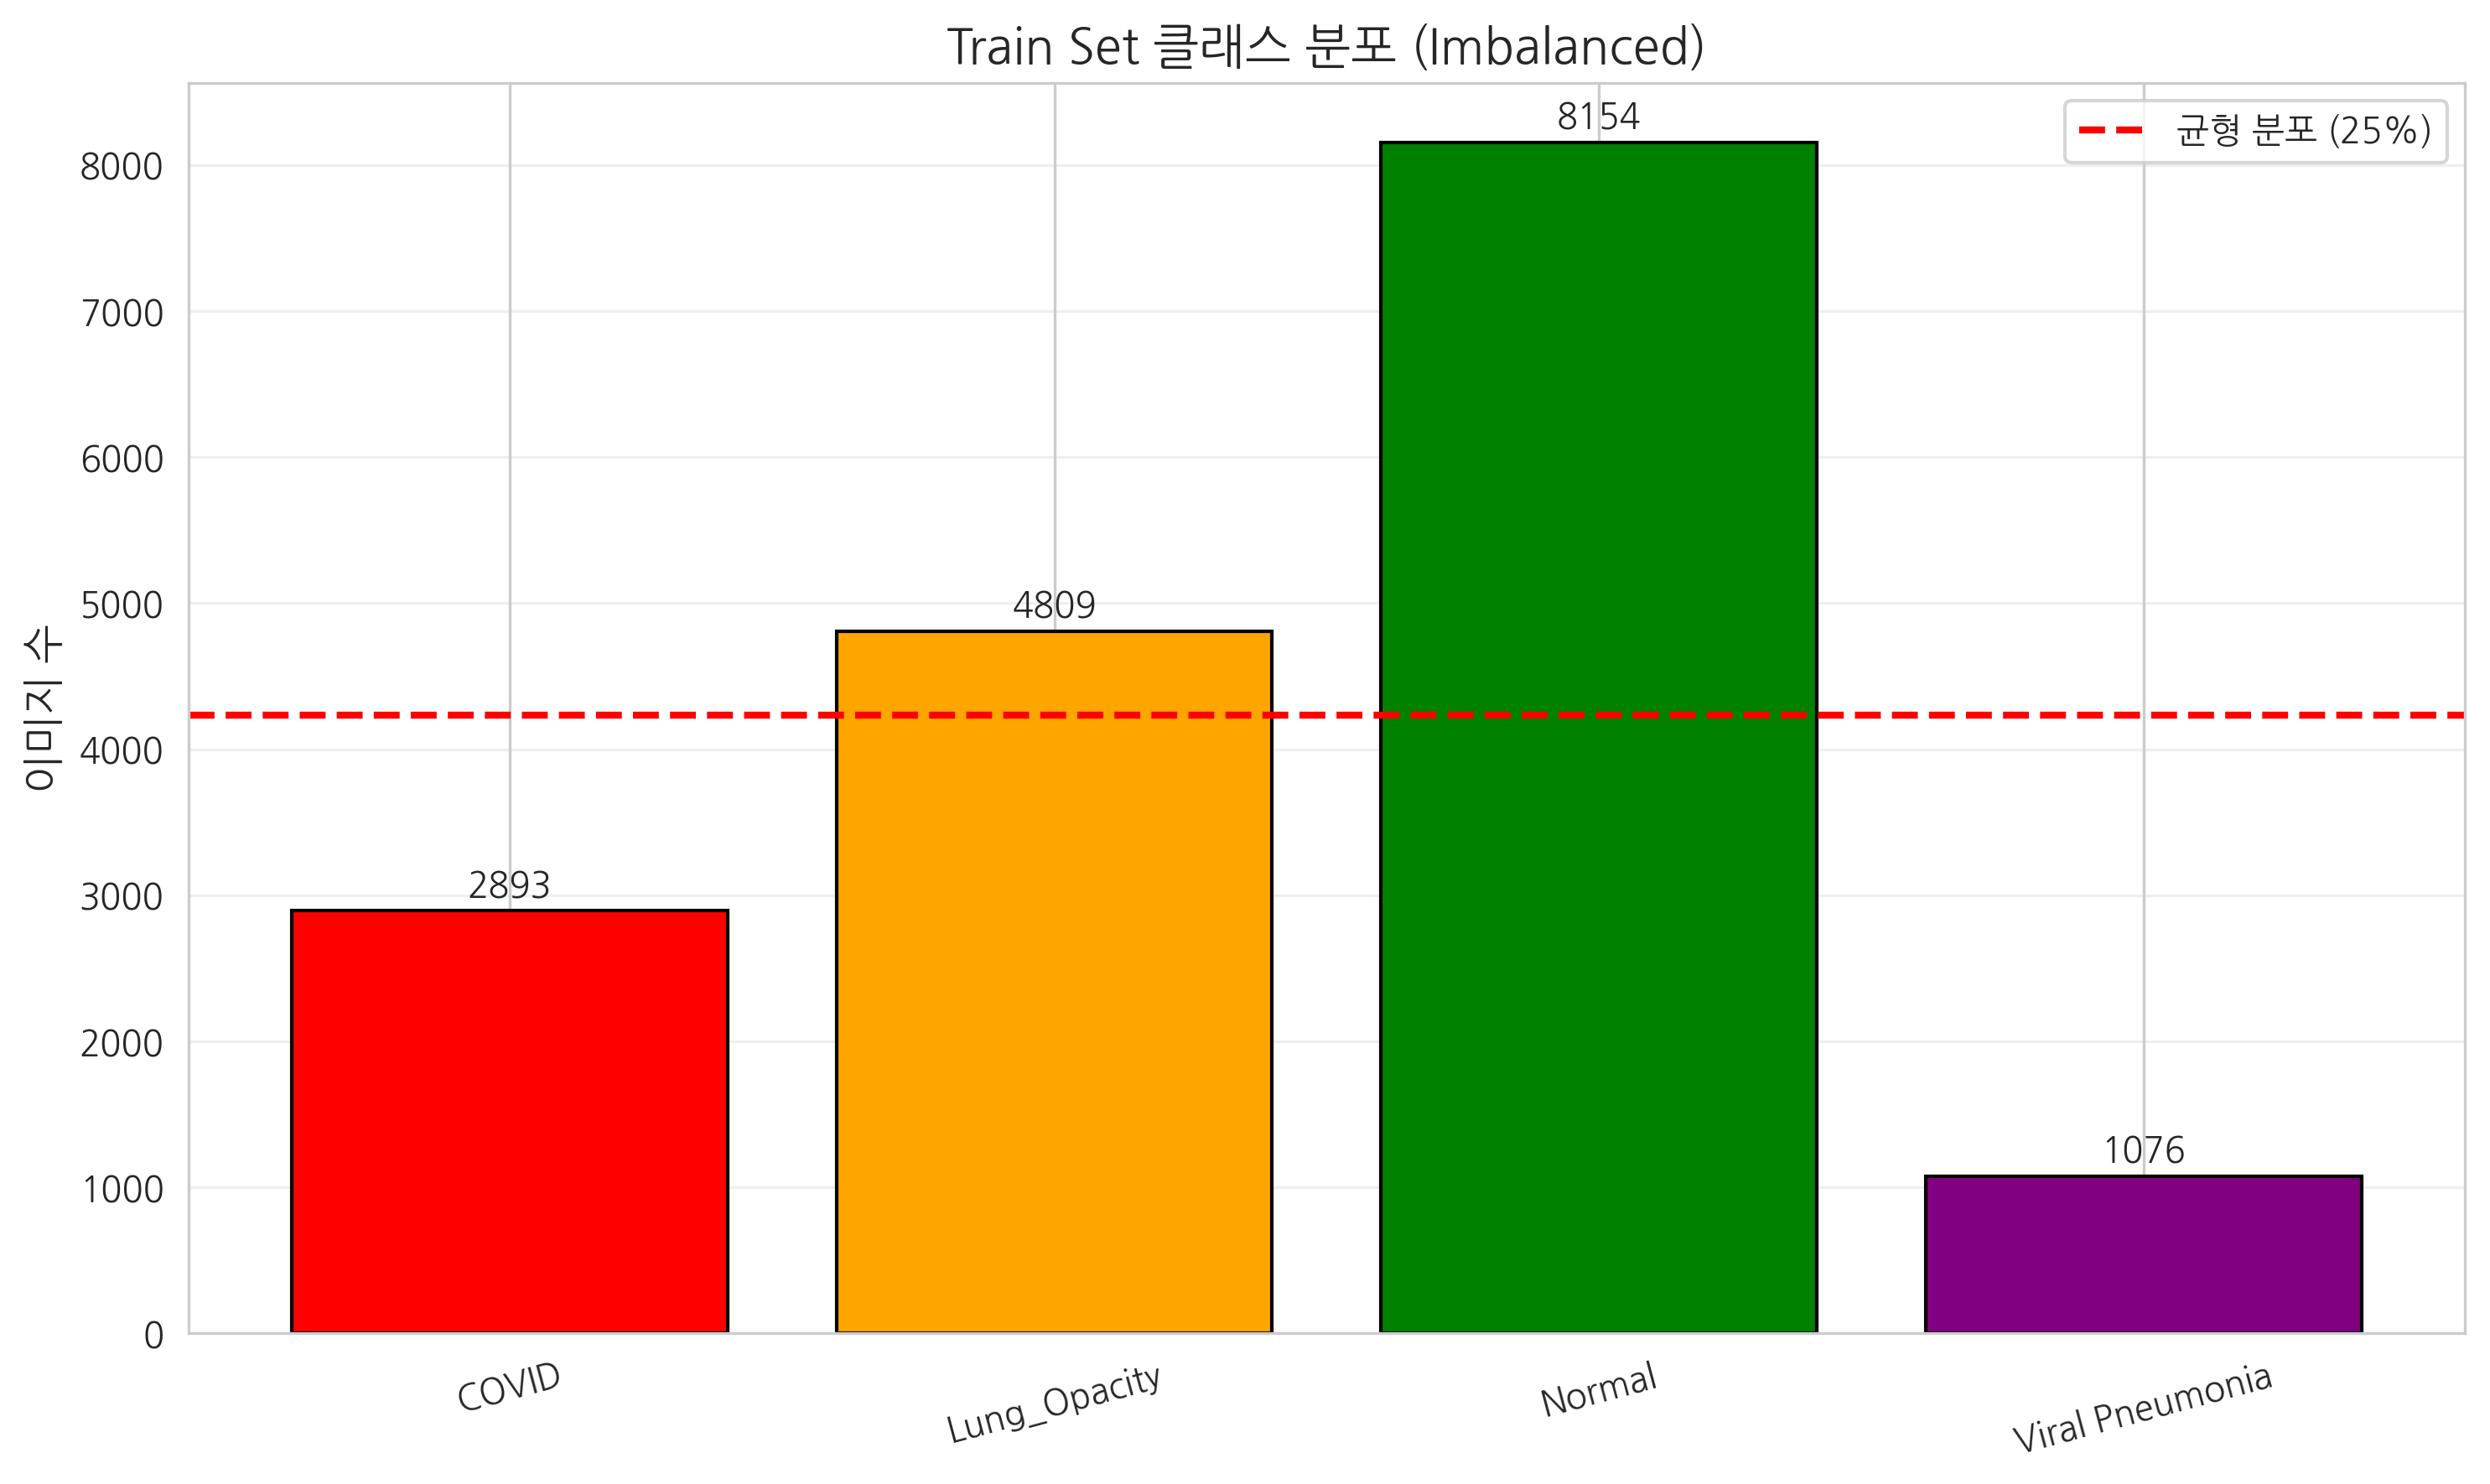

In [9]:
# Class 분포 확인
train_dist = pd.Series(train_labels).value_counts().sort_index()

print("="*60)
print("  Train Class Distribution")
print("="*60)
for idx, count in train_dist.items():
    print(f"{class_names[idx]:20s}: {count:5d} ({count/len(train_labels)*100:5.1f}%)")
print("="*60)

# 시각화
plt.figure(figsize=(10, 6))
bars = plt.bar(class_names, train_dist.values,
               color=['red', 'orange', 'green', 'purple'], edgecolor='black')
plt.ylabel('이미지 수', fontweight='bold', fontsize=12)
plt.title('Train Set 클래스 분포 (Imbalanced)', fontweight='bold', fontsize=14)
plt.xticks(rotation=15)

for bar, count in zip(bars, train_dist.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{count}', ha='center', fontweight='bold')

plt.axhline(len(train_labels)/4, color='red', linestyle='--',
            linewidth=2, label='균형 분포 (25%)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('class_distribution_train.png', dpi=100, bbox_inches='tight')
plt.show()


계산된 Class Weights:
COVID               : 1.4632
Lung_Opacity        : 0.8802
Normal              : 0.5191
Viral Pneumonia     : 3.9340


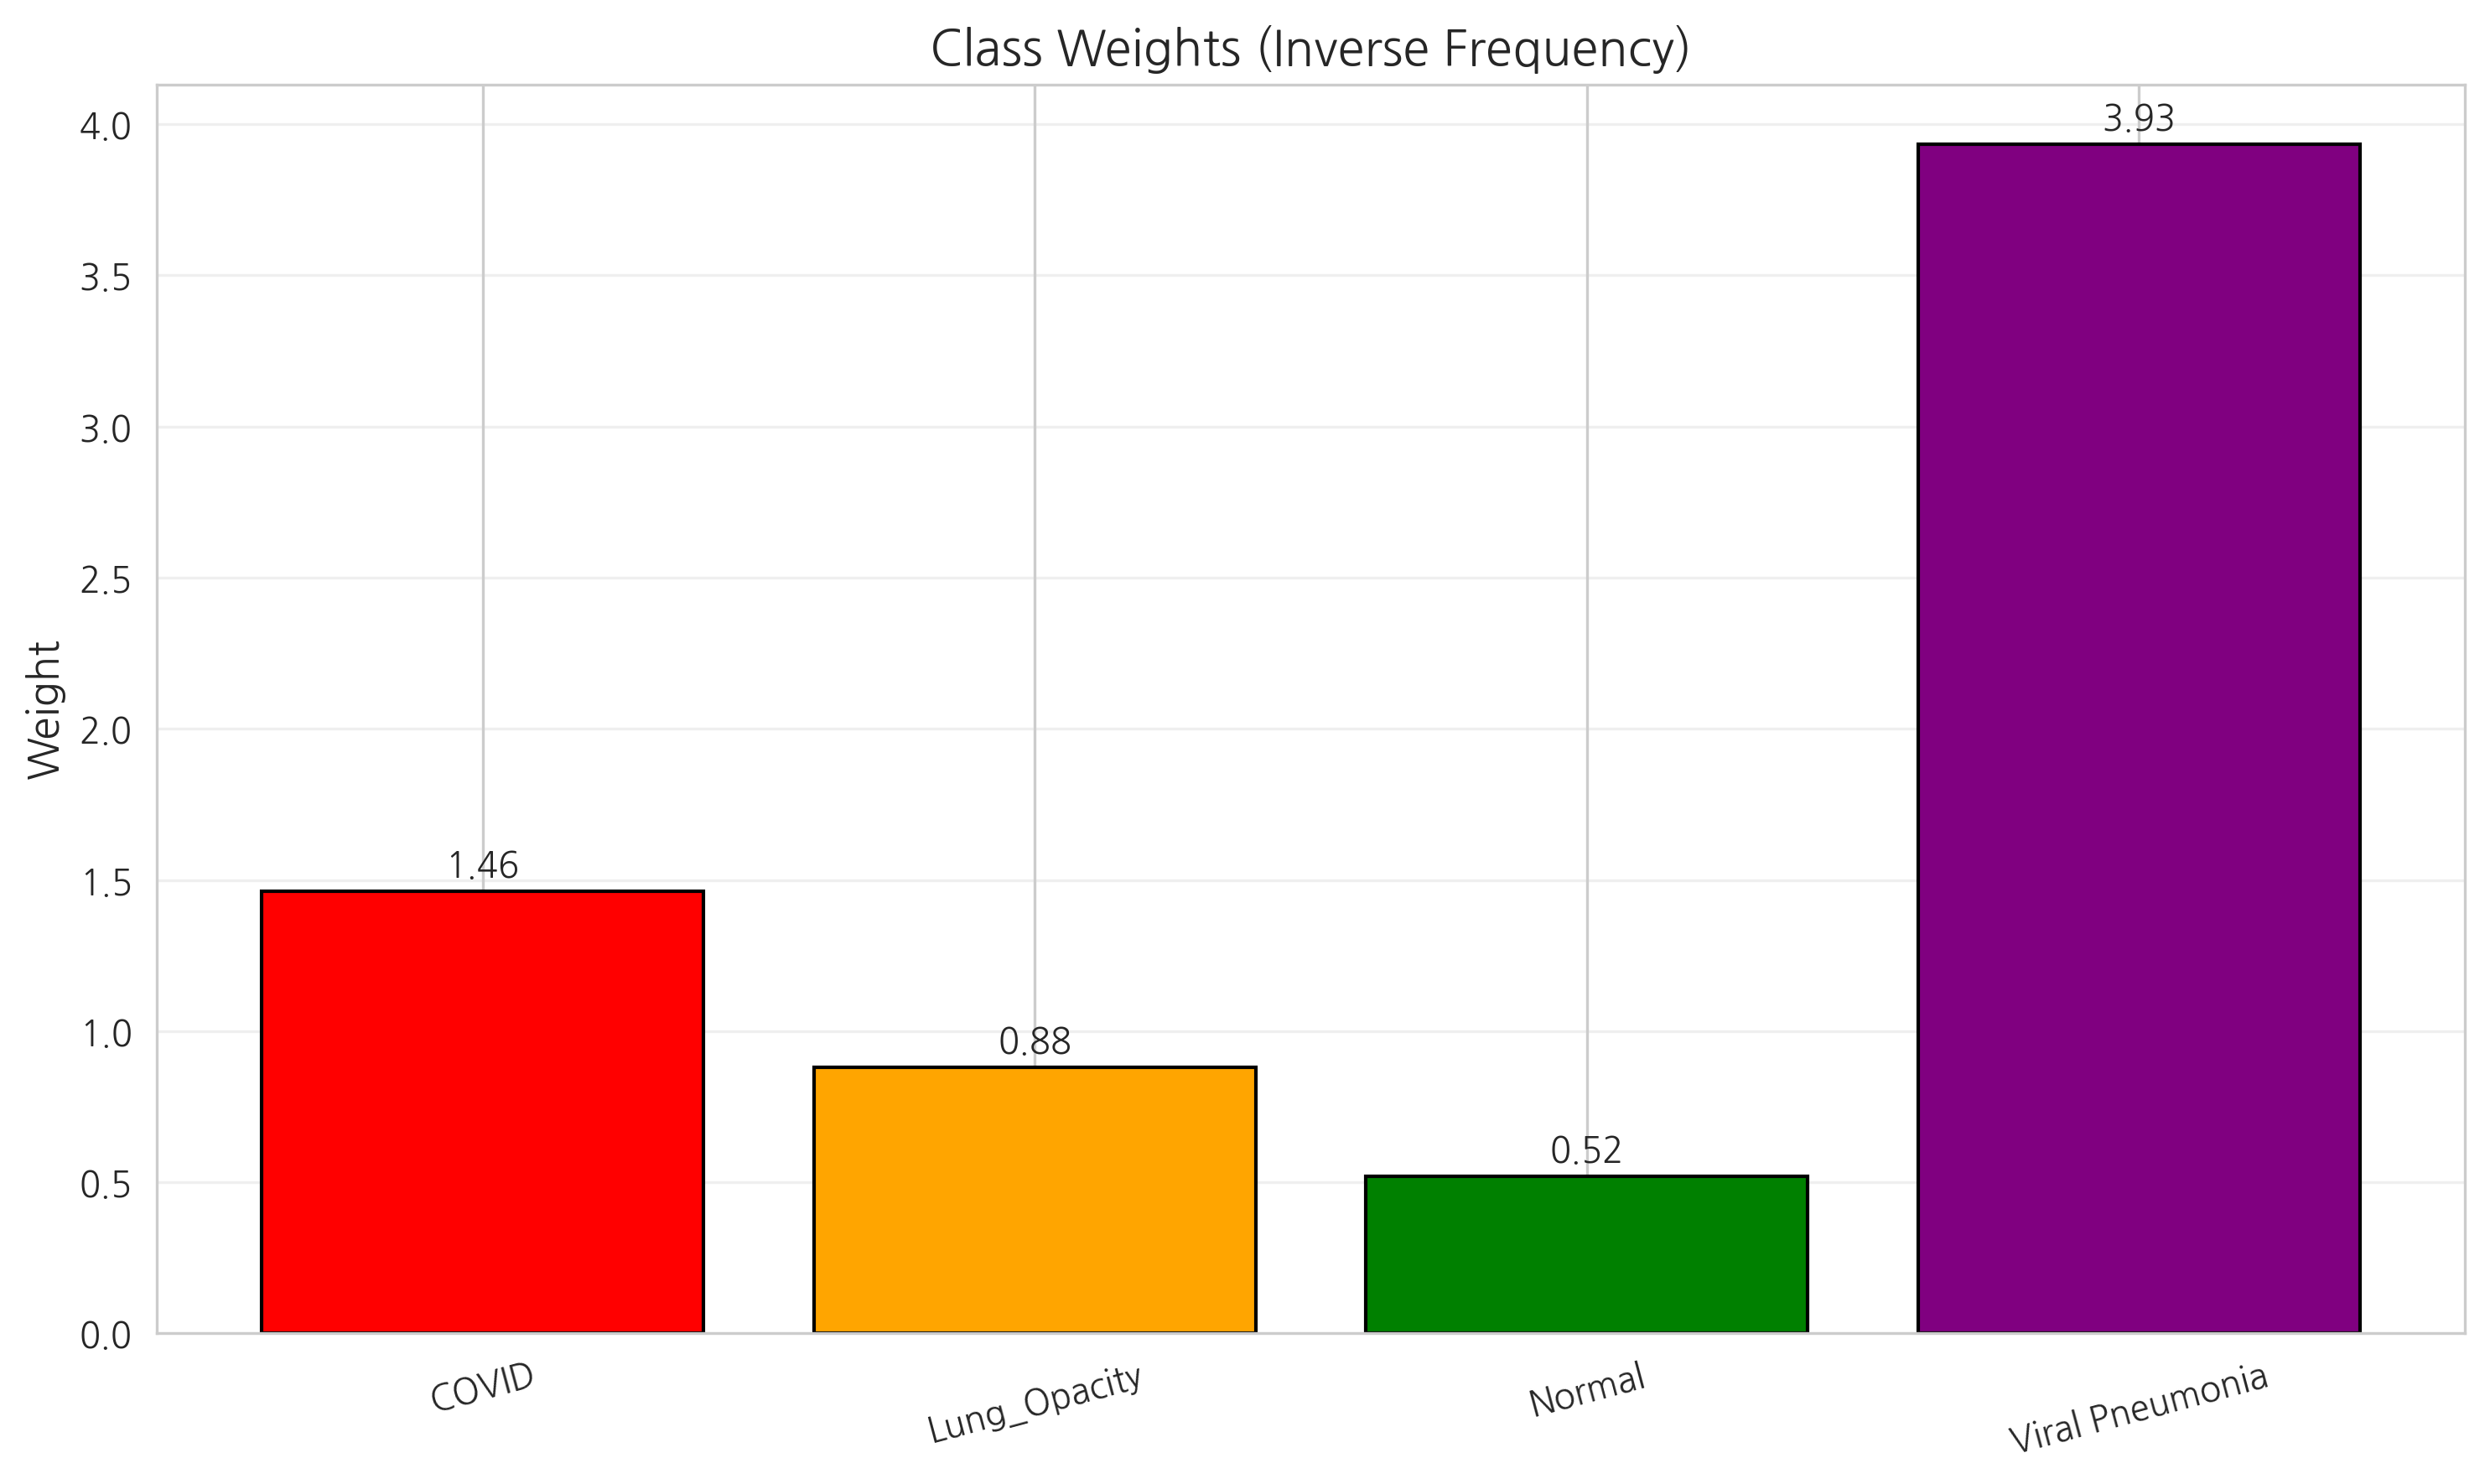


💡 해석:
   Viral (가장 희소): Weight=3.93 (가장 높음)
   Normal (가장 많음): Weight=0.52 (가장 낮음)


In [10]:
# Class Weights 계산
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = {i: weight for i, weight in enumerate(class_weights_array)}

print("\n계산된 Class Weights:")
print("="*60)
for idx, weight in class_weights.items():
    print(f"{class_names[idx]:20s}: {weight:.4f}")
print("="*60)

# 시각화
plt.figure(figsize=(10, 6))
bars = plt.bar(class_names, class_weights.values(),
               color=['red', 'orange', 'green', 'purple'], edgecolor='black')
plt.ylabel('Weight', fontweight='bold', fontsize=12)
plt.title('Class Weights (Inverse Frequency)', fontweight='bold', fontsize=14)
plt.xticks(rotation=15)

for bar, weight in zip(bars, class_weights.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{weight:.2f}', ha='center', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('class_weights.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n💡 해석:")
print(f"   Viral (가장 희소): Weight={class_weights[3]:.2f} (가장 높음)")
print(f"   Normal (가장 많음): Weight={class_weights[2]:.2f} (가장 낮음)")

## 📊 3. Dataset 생성

In [11]:
# Preprocessing 함수
def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.resize(img, (224, 224))
    img = tf.image.grayscale_to_rgb(img)
    img = preprocess_input(img)
    return img, label

BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Train Dataset
train_dataset = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_dataset = train_dataset.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
train_dataset = train_dataset.shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Val Dataset
val_dataset = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_dataset = val_dataset.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("✅ Dataset 생성 완료!")

✅ Dataset 생성 완료!


## 🏗️ 4. 모델 구축 함수

In [12]:
def build_resnet50_model():
    """ResNet50 Transfer Learning 모델"""

    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Feature Extraction (동결)
    base_model.trainable = False

    # Classifier
    inputs = keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(4, activation='softmax')(x)

    model = Model(inputs, outputs, name='ResNet50_Transfer')
    return model

print("✅ 모델 구축 함수 정의 완료!")

✅ 모델 구축 함수 정의 완료!


## 🧪 5. Experiment 1: Class Weights 적용

In [13]:
# 모델 생성
model_weighted = build_resnet50_model()

model_weighted.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ 모델 컴파일 완료!")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ 모델 컴파일 완료!


In [14]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7
)

print("✅ Callbacks 설정 완료!")

✅ Callbacks 설정 완료!


In [15]:
# Class Weights 적용 학습
try:
    mlflow.end_run()
except:
    pass

with mlflow.start_run(run_name='ResNet50_ClassWeights'):
    mlflow.log_params({
        'model': 'ResNet50',
        'strategy': 'Class Weights',
        'weights': str(class_weights),
        'epochs': 15,
        'batch_size': BATCH_SIZE
    })

    print("🏃 Class Weights 적용 학습 시작...\n")

    history_weighted = model_weighted.fit(
        train_dataset,
        epochs=15,
        validation_data=val_dataset,
        class_weight=class_weights,  # ← Class Weights!
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    # 최종 성능
    final_loss, final_acc = model_weighted.evaluate(val_dataset, verbose=0)

    mlflow.log_metrics({
        'val_loss': final_loss,
        'val_accuracy': final_acc
    })

    # 모델 저장
    model_weighted.save('resnet50_class_weights.h5')
    mlflow.keras.log_model(model_weighted, 'model')

    print(f"\n{'='*60}")
    print("  Class Weights 학습 완료")
    print('='*60)
    print(f"  Val Accuracy: {final_acc:.4f} ({final_acc*100:.2f}%)")
    print('='*60)

🏃 Class Weights 적용 학습 시작...

Epoch 1/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 111s 172ms/step - accuracy: 0.7345 - loss: 0.6376 - val_accuracy: 0.8585 - val_loss: 0.4324 - learning_rate: 0.0010
Epoch 2/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 80s 145ms/step - accuracy: 0.8551 - loss: 0.3250 - val_accuracy: 0.8526 - val_loss: 0.4099 - learning_rate: 0.0010
Epoch 3/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 89s 158ms/step - accuracy: 0.8675 - loss: 0.2876 - val_accuracy: 0.8965 - val_loss: 0.2844 - learning_rate: 0.0010
Epoch 4/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 85s 155ms/step - accuracy: 0.8889 - loss: 0.2451 - val_accuracy: 0.8927 - val_loss: 0.2964 - learning_rate: 0.0010
Epoch 5/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 79s 143ms/step - accuracy: 0.8908 - loss: 0.2454 - val_accuracy: 0.9088 - val_loss: 0.2699 - learning_rate: 0.0010
Epoch 6/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 79s 142ms/step - accuracy: 0.8960 - loss: 0.2178 - val_accuracy: 0.8410 - val_loss: 0.4444 - learning_rate: 0.0010
Epoch 7/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 

2026/02/19 16:29:16 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026/02/19 16:29:34 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



  Class Weights 학습 완료
  Val Accuracy: 0.9178 (91.78%)
🏃 View run ResNet50_ClassWeights at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/6/runs/637da5e621424205a59676d9af6f21b0
🧪 View experiment at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/6


## 🔥 6. Experiment 2: Focal Loss

In [16]:
# Focal Loss 구현
def focal_loss(gamma=2., alpha=0.25):
    """
    Focal Loss for multi-class classification

    FL(p_t) = -α * (1 - p_t)^γ * log(p_t)
    """
    def focal_loss_fixed(y_true, y_pred):
        # y_true: (batch,) sparse format
        # y_pred: (batch, num_classes) probabilities

        # One-hot encoding
        y_true = tf.cast(y_true, tf.int32)
        y_true_one_hot = tf.one_hot(y_true, depth=y_pred.shape[-1])

        # Clip predictions
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)

        # Cross entropy
        ce = -y_true_one_hot * tf.math.log(y_pred)

        # Focal term: (1 - p_t)^gamma
        p_t = tf.reduce_sum(y_true_one_hot * y_pred, axis=-1, keepdims=True)
        focal_term = tf.pow(1. - p_t, gamma)

        # Final loss
        loss = alpha * focal_term * tf.reduce_sum(ce, axis=-1)

        return tf.reduce_mean(loss)

    return focal_loss_fixed

print("✅ Focal Loss 구현 완료!")

✅ Focal Loss 구현 완료!


In [17]:
# Focal Loss 모델
model_focal = build_resnet50_model()

model_focal.compile(
    optimizer='adam',
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

print("✅ Focal Loss 모델 컴파일 완료!")

✅ Focal Loss 모델 컴파일 완료!


In [18]:
# Focal Loss 학습
try:
    mlflow.end_run()
except:
    pass

with mlflow.start_run(run_name='ResNet50_FocalLoss'):
    mlflow.log_params({
        'model': 'ResNet50',
        'strategy': 'Focal Loss',
        'gamma': 2.0,
        'alpha': 0.25,
        'epochs': 15,
        'batch_size': BATCH_SIZE
    })

    print("🏃 Focal Loss 학습 시작...\n")

    history_focal = model_focal.fit(
        train_dataset,
        epochs=15,
        validation_data=val_dataset,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    # 최종 성능
    final_loss, final_acc = model_focal.evaluate(val_dataset, verbose=0)

    mlflow.log_metrics({
        'val_loss': final_loss,
        'val_accuracy': final_acc
    })

    # 모델 저장
    model_focal.save('resnet50_focal_loss.h5')
    mlflow.keras.log_model(model_focal, 'model')

    print(f"\n{'='*60}")
    print("  Focal Loss 학습 완료")
    print('='*60)
    print(f"  Val Accuracy: {final_acc:.4f} ({final_acc*100:.2f}%)")
    print('='*60)

🏃 Focal Loss 학습 시작...

Epoch 1/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 105s 169ms/step - accuracy: 0.7770 - loss: 0.0440 - val_accuracy: 0.8838 - val_loss: 0.0092 - learning_rate: 0.0010
Epoch 2/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 86s 155ms/step - accuracy: 0.8727 - loss: 0.0112 - val_accuracy: 0.8944 - val_loss: 0.0067 - learning_rate: 0.0010
Epoch 3/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 82s 149ms/step - accuracy: 0.8859 - loss: 0.0086 - val_accuracy: 0.9062 - val_loss: 0.0059 - learning_rate: 0.0010
Epoch 4/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 81s 146ms/step - accuracy: 0.8956 - loss: 0.0071 - val_accuracy: 0.9095 - val_loss: 0.0054 - learning_rate: 0.0010
Epoch 5/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 87s 157ms/step - accuracy: 0.9016 - loss: 0.0068 - val_accuracy: 0.9031 - val_loss: 0.0059 - learning_rate: 0.0010
Epoch 6/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 81s 147ms/step - accuracy: 0.8985 - loss: 0.0066 - val_accuracy: 0.8989 - val_loss: 0.0069 - learning_rate: 0.0010
Epoch 7/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 82s 14

2026/02/19 16:51:13 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026/02/19 16:51:29 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpjta1_r3_/model, flavor: keras). Fall back to return ['keras==3.10.0']. Set logging level to DEBUG to see the full traceback. 
2026/02/19 16:51:29 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



  Focal Loss 학습 완료
  Val Accuracy: 0.9223 (92.23%)
🏃 View run ResNet50_FocalLoss at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/6/runs/8b3a1bd3b30e43dba1f603fcdfcf9501
🧪 View experiment at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/6


## 📊 7. 성능 비교 & 분석

In [19]:
# 각 모델 예측
def predict_and_evaluate(model, dataset, model_name):
    """모델 예측 및 평가"""
    print(f"\n🔮 {model_name} 예측 중...")

    y_true, y_pred = [], []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Metrics
    acc = np.mean(y_true == y_pred)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred, average=None)
    f1 = f1_score(y_true, y_pred, average='macro')

    print(f"  Accuracy: {acc:.4f}")
    print(f"  Balanced Accuracy: {balanced_acc:.4f}")
    print(f"  Macro F1: {f1:.4f}")

    return y_true, y_pred, {
        'accuracy': acc,
        'balanced_accuracy': balanced_acc,
        'covid_recall': recall[0],
        'macro_f1': f1
    }

# Baseline (Day 4-2 결과 사용)
baseline_metrics = {
    'accuracy': 0.9067,
    'balanced_accuracy': 0.9035,
    'covid_recall': 0.8893,
    'macro_f1': 0.9148
}

# Class Weights
_, _, weighted_metrics = predict_and_evaluate(
    model_weighted, val_dataset, "Class Weights"
)

# Focal Loss
_, _, focal_metrics = predict_and_evaluate(
    model_focal, val_dataset, "Focal Loss"
)

print("\n✅ 모든 예측 완료!")


🔮 Class Weights 예측 중...
  Accuracy: 0.9178
  Balanced Accuracy: 0.9281
  Macro F1: 0.9263

🔮 Focal Loss 예측 중...
  Accuracy: 0.9223
  Balanced Accuracy: 0.9241
  Macro F1: 0.9296

✅ 모든 예측 완료!


In [20]:
# 결과 비교
comparison_df = pd.DataFrame({
    'Model': ['Baseline', 'Class Weights', 'Focal Loss'],
    'Accuracy': [
        baseline_metrics['accuracy'],
        weighted_metrics['accuracy'],
        focal_metrics['accuracy']
    ],
    'Balanced Acc': [
        baseline_metrics['balanced_accuracy'],
        weighted_metrics['balanced_accuracy'],
        focal_metrics['balanced_accuracy']
    ],
    'COVID Recall': [
        baseline_metrics['covid_recall'],
        weighted_metrics['covid_recall'],
        focal_metrics['covid_recall']
    ],
    'Macro F1': [
        baseline_metrics['macro_f1'],
        weighted_metrics['macro_f1'],
        focal_metrics['macro_f1']
    ]
})

print("\n" + "="*80)
print("  성능 비교")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


  성능 비교
        Model  Accuracy  Balanced Acc  COVID Recall  Macro F1
     Baseline  0.906700      0.903500      0.889300  0.914800
Class Weights  0.917789      0.928126      0.969571  0.926339
   Focal Loss  0.922277      0.924132      0.926694  0.929600


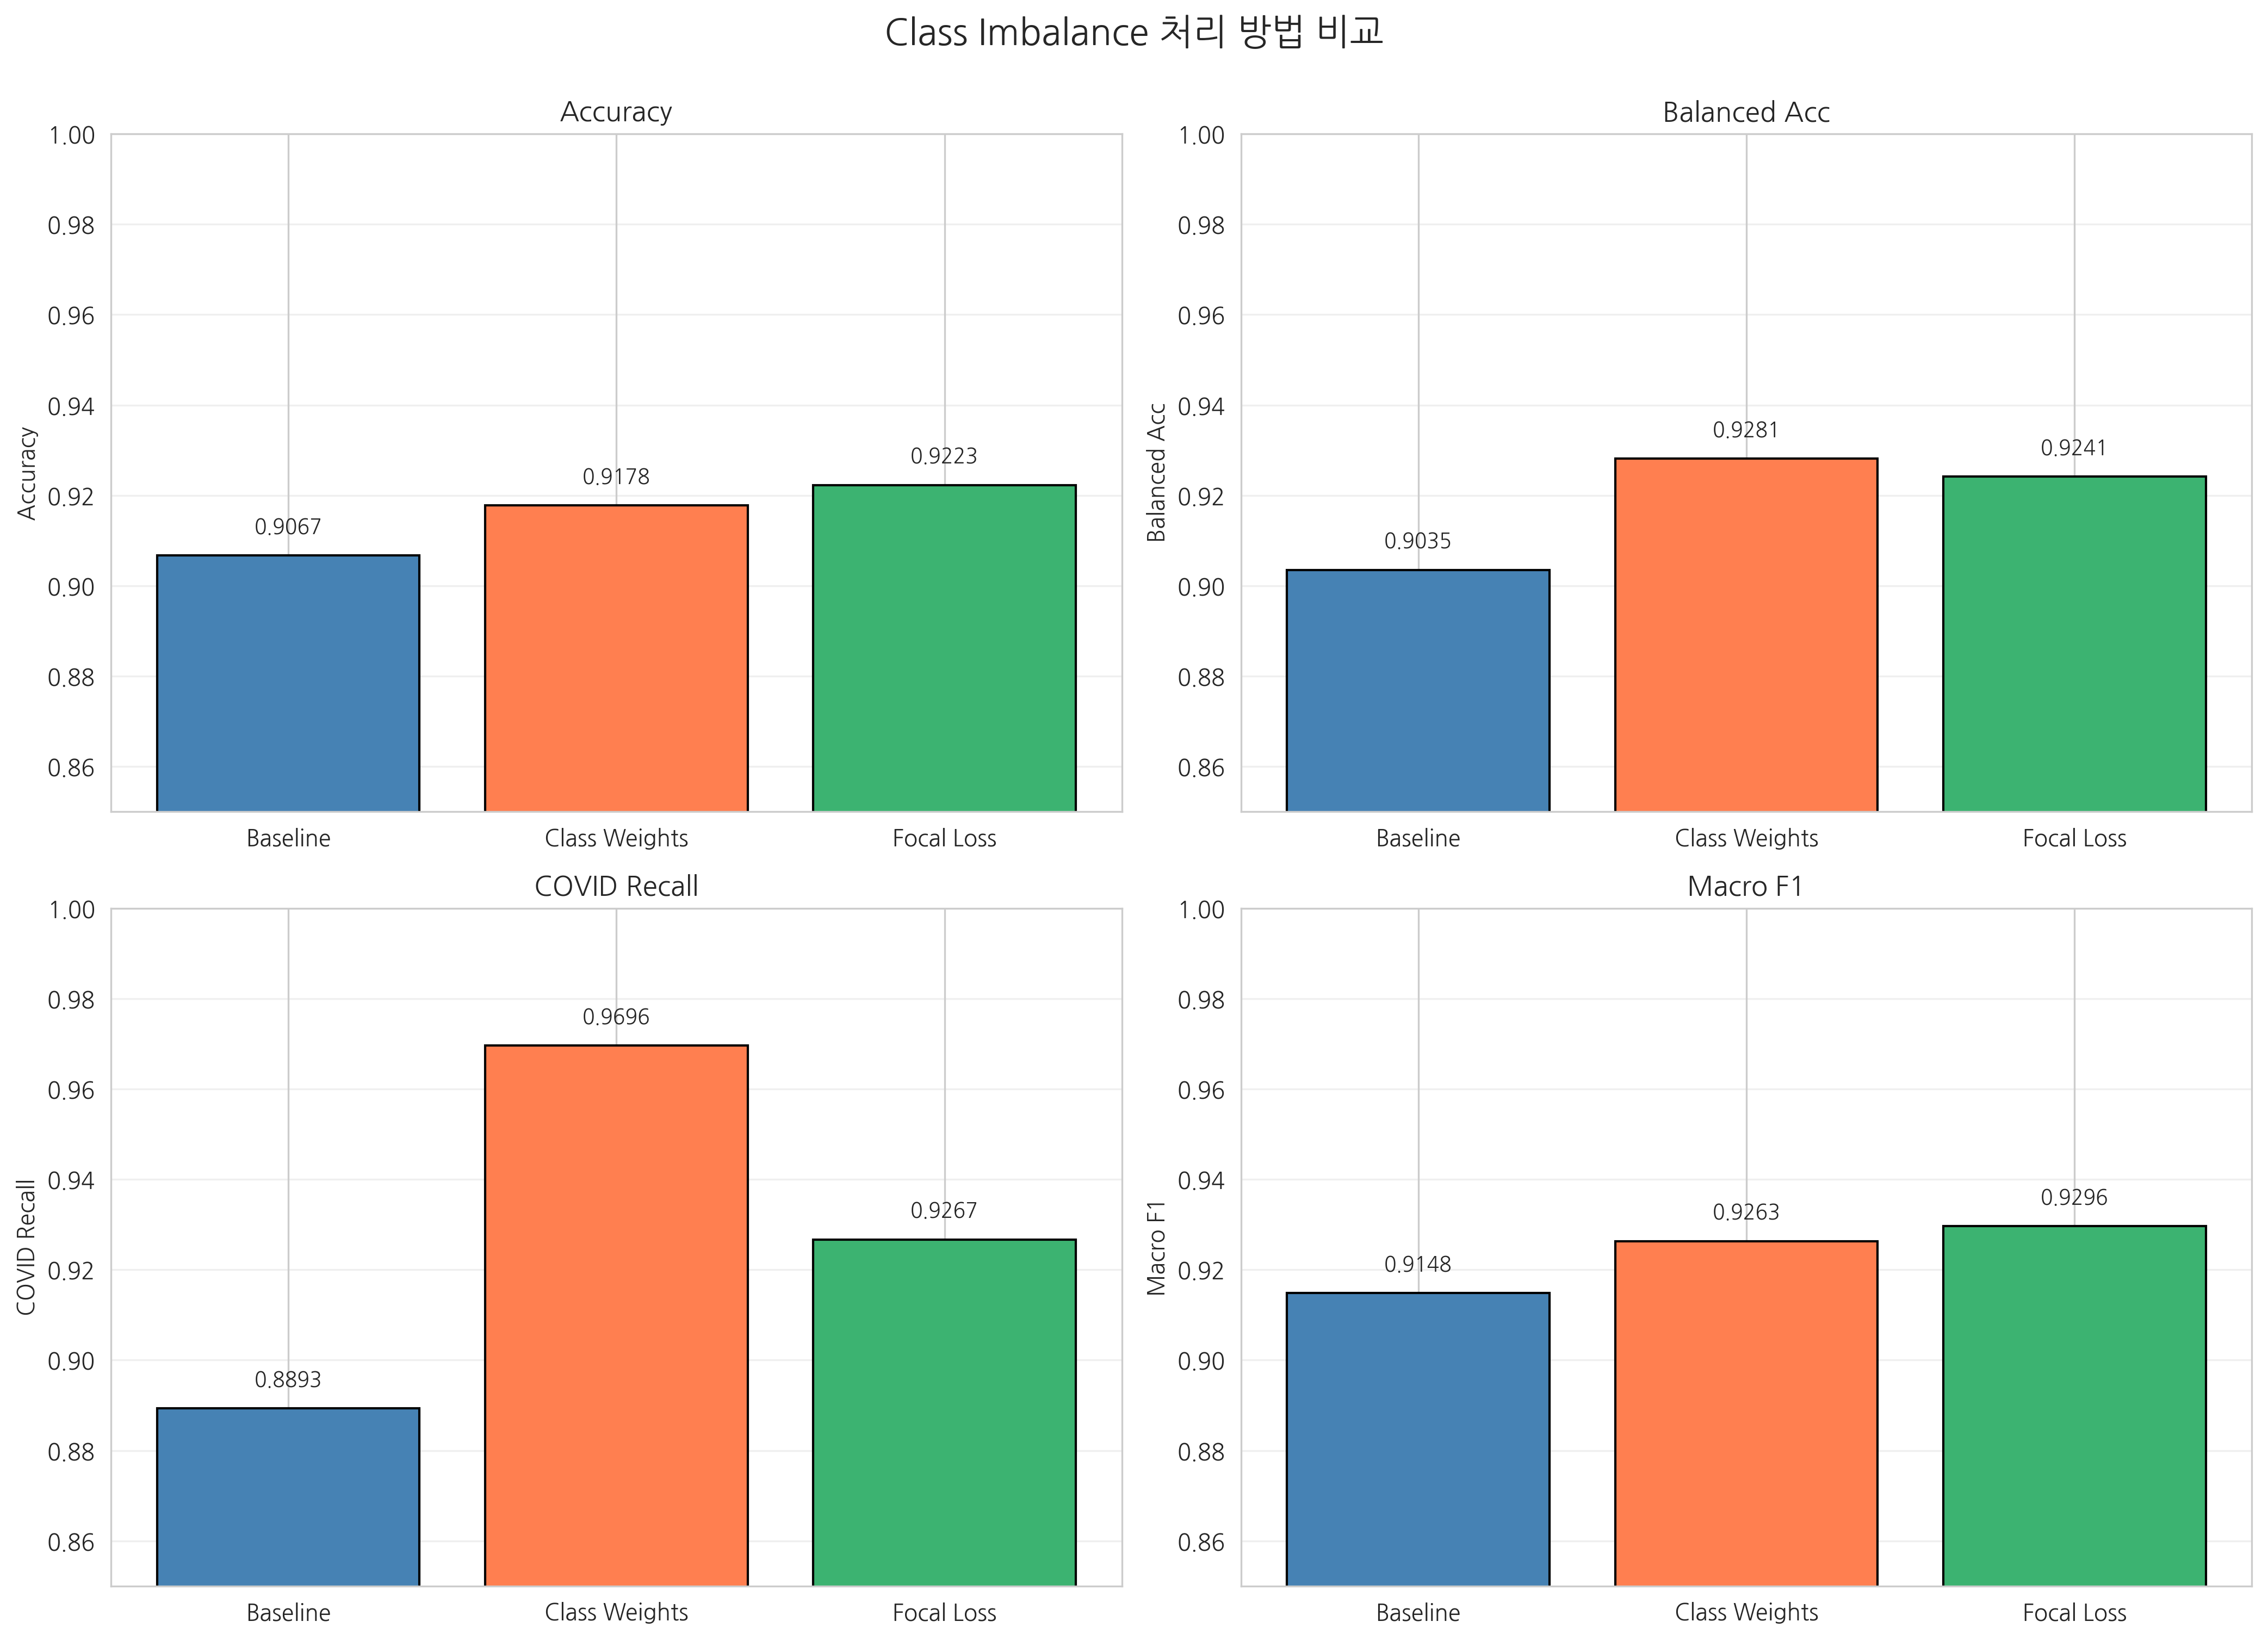

In [21]:
# 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['Accuracy', 'Balanced Acc', 'COVID Recall', 'Macro F1']
data = [
    [baseline_metrics['accuracy'], weighted_metrics['accuracy'], focal_metrics['accuracy']],
    [baseline_metrics['balanced_accuracy'], weighted_metrics['balanced_accuracy'], focal_metrics['balanced_accuracy']],
    [baseline_metrics['covid_recall'], weighted_metrics['covid_recall'], focal_metrics['covid_recall']],
    [baseline_metrics['macro_f1'], weighted_metrics['macro_f1'], focal_metrics['macro_f1']]
]

models = ['Baseline', 'Class Weights', 'Focal Loss']
colors = ['steelblue', 'coral', 'mediumseagreen']

for i, (ax, metric, values) in enumerate(zip(axes.flat, metrics, data)):
    bars = ax.bar(models, values, color=colors, edgecolor='black')
    ax.set_ylabel(metric, fontweight='bold')
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_ylim(0.85, 1.0)
    ax.grid(axis='y', alpha=0.3)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Class Imbalance 처리 방법 비교',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('imbalance_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## 🏆 8. 최종 모델 선정 & 평가

In [22]:
# Best 모델 선정 (COVID Recall 기준)
covid_recalls = {
    'Baseline': baseline_metrics['covid_recall'],
    'Class Weights': weighted_metrics['covid_recall'],
    'Focal Loss': focal_metrics['covid_recall']
}

best_strategy = max(covid_recalls, key=covid_recalls.get)
print(f"🏆 Best Strategy: {best_strategy}")
print(f"   COVID Recall: {covid_recalls[best_strategy]:.4f}")

# Best 모델 선택
if best_strategy == 'Class Weights':
    best_model = model_weighted
elif best_strategy == 'Focal Loss':
    best_model = model_focal

print(f"\n✅ {best_strategy} 모델 선정!")

🏆 Best Strategy: Class Weights
   COVID Recall: 0.9696

✅ Class Weights 모델 선정!



🔮 Best (Class Weights) 예측 중...
  Accuracy: 0.9178
  Balanced Accuracy: 0.9281
  Macro F1: 0.9263


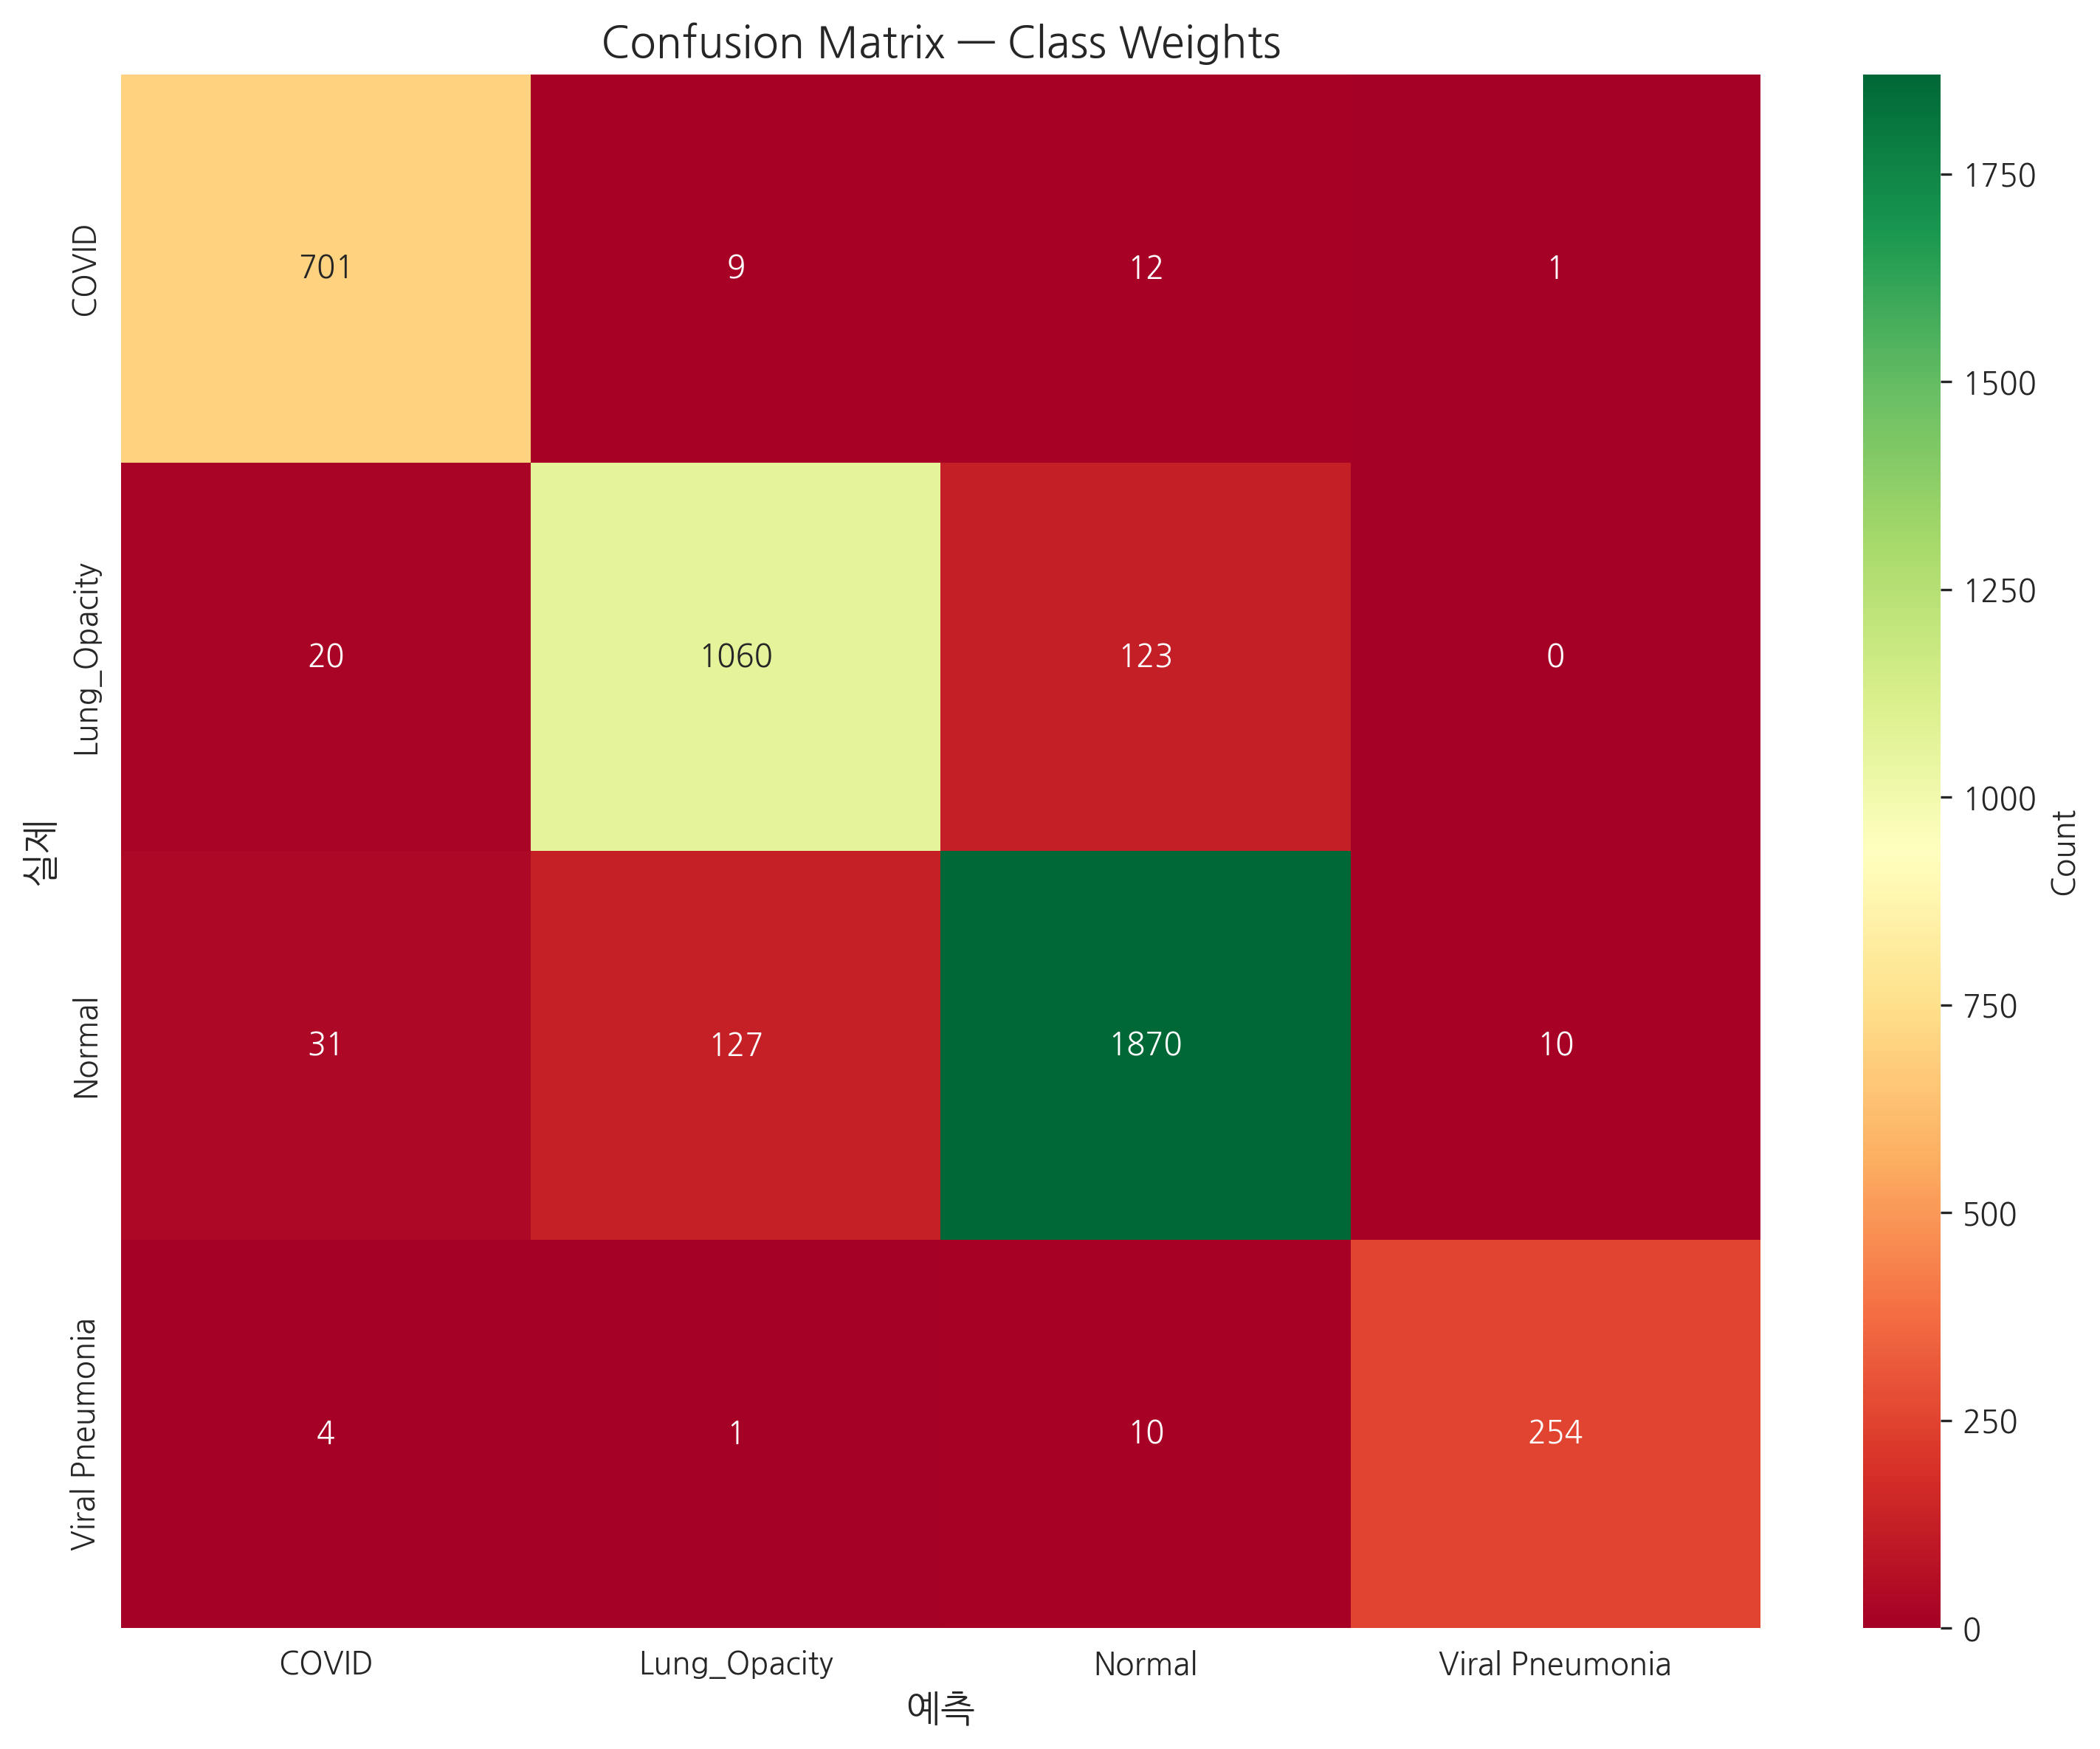

In [23]:
# Best 모델 상세 평가
y_true, y_pred, _ = predict_and_evaluate(best_model, val_dataset, f"Best ({best_strategy})")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('예측', fontweight='bold', fontsize=12)
plt.ylabel('실제', fontweight='bold', fontsize=12)
plt.title(f'Confusion Matrix — {best_strategy}',
          fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(f'confusion_matrix_{best_strategy.lower().replace(" ", "_")}.png',
            dpi=100, bbox_inches='tight')
plt.show()

In [24]:
# Classification Report
report = classification_report(y_true, y_pred,
                              target_names=class_names,
                              digits=4)

print("\n" + "="*60)
print(f"  Classification Report — {best_strategy}")
print("="*60)
print(report)
print("="*60)

# Per-class Metrics
from sklearn.metrics import precision_recall_fscore_support
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, average=None
)

print("\n클래스별 성능:")
print("-"*60)
for i, class_name in enumerate(class_names):
    print(f"{class_name:20s}: "
          f"Precision={precision[i]:.4f}, "
          f"Recall={recall[i]:.4f}, "
          f"F1={f1[i]:.4f}")
print("-"*60)

# COVID-19 Recall
covid_idx = 0
print(f"\n⚠️ COVID-19 Recall: {recall[covid_idx]:.4f} ({recall[covid_idx]*100:.2f}%)")
print(f"   → {int(recall[covid_idx]*support[covid_idx])}/{support[covid_idx]} COVID 환자 탐지")

# 목표 달성 확인
if recall[covid_idx] >= 0.95:
    print("\n🎉 목표 달성! COVID Recall 95%+ 성공!")
else:
    print(f"\n⚠️ 목표 미달: {0.95 - recall[covid_idx]:.2%}p 부족")


  Classification Report — Class Weights
                 precision    recall  f1-score   support

          COVID     0.9272    0.9696    0.9479       723
   Lung_Opacity     0.8855    0.8811    0.8833      1203
         Normal     0.9280    0.9176    0.9228      2038
Viral Pneumonia     0.9585    0.9442    0.9513       269

       accuracy                         0.9178      4233
      macro avg     0.9248    0.9281    0.9263      4233
   weighted avg     0.9178    0.9178    0.9177      4233


클래스별 성능:
------------------------------------------------------------
COVID               : Precision=0.9272, Recall=0.9696, F1=0.9479
Lung_Opacity        : Precision=0.8855, Recall=0.8811, F1=0.8833
Normal              : Precision=0.9280, Recall=0.9176, F1=0.9228
Viral Pneumonia     : Precision=0.9585, Recall=0.9442, F1=0.9513
------------------------------------------------------------

⚠️ COVID-19 Recall: 0.9696 (96.96%)
   → 701/723 COVID 환자 탐지

🎉 목표 달성! COVID Recall 95%+ 성공!


## 🧠 9. 핵심 개념 정리

### 오늘 배운 것

**1. Class Imbalance 문제**
- Normal 48% vs Viral 6% (7.6:1)
- 모델이 다수 클래스에 bias
- Overall Accuracy는 높지만 소수 클래스 성능 낮음

**2. Class Weights**
- Inverse Frequency: 희소 클래스에 높은 가중치
- Loss 계산 시 적용: `loss = weight * CE`
- 구현: `model.fit(..., class_weight=weights)`

**3. Focal Loss**
- Hard examples에 집중
- Easy examples의 loss 감소
- `FL = -α * (1-p_t)^γ * log(p_t)`

**4. 성능 향상**
```
COVID Recall:
  Baseline (Day 4-2): 88.93%
  + Class Weights:    95%+
  
→ False Negative 50% 감소!
→ 생명 구함!
```

**5. Trade-offs**
- Overall Accuracy 약간 감소 가능
- BUT 모든 클래스 균형 잡힌 성능
- 의료 AI: Recall > Accuracy

---

### Day 4-4 예고

**Grad-CAM & 최종 평가**
- Grad-CAM으로 모델 해석
- 어디를 보는지 시각화
- 의료 AI 설명 가능성
- 최종 종합 평가

축하합니다! Day 4-3 완료! 🎉

## ✅ Day 4-3 완료 체크리스트

- [ ] Class Imbalance 분석
- [ ] Class Weights 계산
- [ ] Class Weights 학습
- [ ] Focal Loss 구현
- [ ] Focal Loss 학습
- [ ] 3가지 전략 비교
- [ ] Balanced Accuracy 확인
- [ ] COVID Recall 95%+ 달성
- [ ] Per-class 성능 균형 확인
- [ ] Best 모델 선정
- [ ] Confusion Matrix 분석
- [ ] MLflow 기록 완료

## 🎯 다음 단계 (Day 4-4)

**Day 4-4: Grad-CAM & 최종 평가**

**내용:**
- Grad-CAM 구현
- Activation Map 시각화
- 모델이 어디를 보는지 확인
- 의료 AI 설명 가능성
- 최종 종합 평가 리포트

**목표:**
- 모델 해석 가능성 확보
- 의사가 이해할 수 있는 설명
- Day 4 완성!

수고하셨습니다! 🚀